# Homework 4 - Question 2: Federated Learning & Privacy


**Course:** Security and Privacy in Machine Learning

**Student Name:** Farzan Rahmani  

**Student ID:** 403210725

---

## Objective
This assignment elevates standard Federated Learning (FL) concepts to a graduate level. You will move beyond toy examples to implement realistic heterogeneity, state-of-the-art attacks, and privacy leakage demonstrations.

**Key Tasks:**
1.  **Realistic Non-IID Data:** Implement a **Dirichlet distribution** split ($Dir(\alpha)$) to simulate realistic client heterogeneity.
2.  **Stealthy Backdoor:** Implement a **Model Replacement Attack** using a blended trigger (watermark) and update scaling.
3.  **Defenses:** Implement **Norm Clipping** and **Coordinate-wise Median** to mitigate the attack.
4.  **Deep Leakage (Gradient Inversion):** Demonstrate why "sharing gradients is safe" is a myth by reconstructing an image from a raw gradient.
5.  **Differential Privacy:** Apply formal DP (Clipping + Noise) to defend against the inversion attack.

**Dataset:** CIFAR-10 (32x32 Color Images).

In [1]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


## Part 0: Architecture & Dataset
We use a stronger CNN than typical MNIST tutorials because CIFAR-10 is harder. No changes needed here.

In [2]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    return train_set, test_set

train_data, test_data = get_cifar10()

## Part 1: Simulating Realistic Heterogeneity (Dirichlet Split)

### **Theory & Tutorial**
In standard centralized learning, we assume data is **I.I.D.** (Independent and Identically Distributed)—meaning every shuffle of the data looks roughly the same. In Federated Learning (FL), this assumption breaks. A user in Tokyo sees different images than a user in New York. This statistical heterogeneity causes "client drift," making training unstable.

To simulate this in a lab setting, researchers use the **Dirichlet Distribution** ($Dir(\alpha)$). The parameter $\alpha$ controls the degree of non-IIDness:
* **$\alpha \to \infty$:** The distribution is uniform (I.I.D.). Every client has a roughly equal mix of all 10 classes.
* **$\alpha \to 0$ (e.g., 0.1):** Extreme heterogeneity. A client might possess only "Cars" and "Birds," with zero data for other classes. This is where FL algorithms struggle the most.

**Key Reference:**
> *Hsu, T. M. H., Qi, H., & Brown, M. (2019). Measuring the effects of non-identical data distribution for federated visual classification.* > This paper standardized the use of Dirichlet splits ($\alpha=0.1, 0.5$) to benchmark FL algorithms.

**Your Task:**
Implement `split_dirichlet`. Instead of shuffling the dataset globally, you must group data by label and sample proportions from a Dirichlet distribution to allocate specific classes to specific clients.

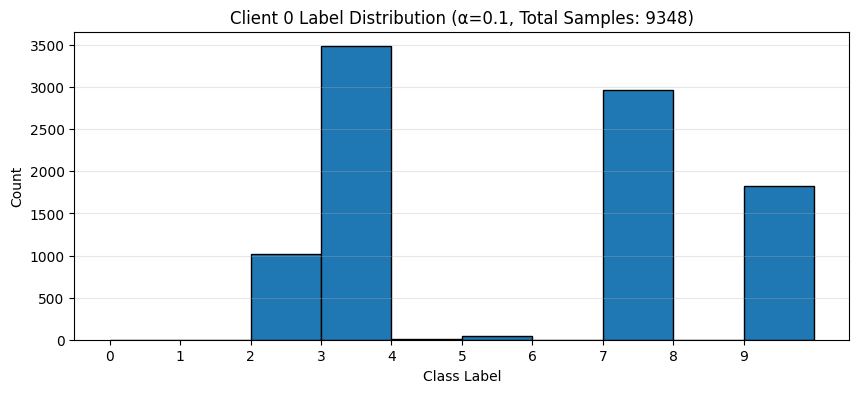

In [3]:
def split_dirichlet(dataset, num_clients, alpha=0.5):
    """
    Returns a list of `num_clients` Subsets using Dirichlet sampling.
    """
    labels = np.array(dataset.targets)
    num_classes = 10
    client_idcs = [[] for _ in range(num_clients)]

    # TODO: For each class k, split its indices among clients using Dirichlet
    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)

        # TODO: Sample proportions ~ Dir(alpha)
        # proportions = ...
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = proportions / proportions.sum() # Normalize proportions to sum to 1

        # TODO: Split idx_k based on proportions and assign to client_idcs
        # Hint: np.split is useful here
        proportions = np.cumsum(proportions * len(idx_k)).astype(int)[:-1]
        idx_k_split = np.split(idx_k, proportions)

        # Assign to client_idcs
        for client_id, idx in enumerate(idx_k_split):
            client_idcs[client_id].extend(idx.tolist())

        # pass

    return [Subset(dataset, idcs) for idcs in client_idcs]

# TEST YOUR CODE
clients = split_dirichlet(train_data, 10, alpha=0.1)
# Visualize the distribution of labels for Client 0 (Histogram)

client_0_labels = [train_data.targets[i] for i in clients[0].indices]
plt.figure(figsize=(10, 4))
plt.hist(client_0_labels, bins=10, range=(0, 10), edgecolor='black')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title(f'Client 0 Label Distribution (α=0.1, Total Samples: {len(client_0_labels)})')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [4]:
# Print distribution for all clients
print("\nLabel distribution across all clients:")
for i, client in enumerate(clients):
    labels_count = np.bincount([train_data.targets[idx] for idx in client.indices], minlength=10)
    print(f"Client {i}: {labels_count}")


Label distribution across all clients:
Client 0: [   0    0 1015 3485    4   47    0 2966    0 1831]
Client 1: [  24    0  240  994 4559    0 2299    1  182    0]
Client 2: [   0  412 2539  492  390    0  223    0    0    0]
Client 3: [1495   52   58    0    0    0   60    0    0   85]
Client 4: [3479    0  209    0    0  753    0    0    0   30]
Client 5: [   0    9  100    7   29    3    0    0 4336    0]
Client 6: [   1    0    0    0    0 3102    1 2017    0    0]
Client 7: [   0 1489    0   21    0    1   66   15    0    1]
Client 8: [   0 3034  838    0    0  498 2350    0  458 2650]
Client 9: [  1   4   1   1  18 596   1   1  24 403]


## Part 2: Stealthy Backdoor & Model Replacement

### **Theory & Tutorial**
A **Backdoor Attack** (or Trojan) teaches the model to behave normally on clean data but misclassify any image containing a specific "trigger" (e.g., a pixel pattern) as a target label (e.g., "Bird").

**The Problem for Attackers:** In FedAvg, the server aggregates updates by averaging:
$$\Delta W_{global} = \frac{1}{N} \sum_{i=1}^{N} \Delta W_i$$
If you are 1 malicious client among 10 ($N=10$), your backdoor update is divided by 10. The honest updates from the other 9 clients will likely overwrite your backdoor (a phenomenon called "catastrophic forgetting").

**The Solution: Model Replacement:** To survive averaging, the attacker scales their update vector by a factor of $\gamma = \frac{N}{\eta}$. By boosting their update magnitude, they mathematically cancel out the honest clients' contributions, replacing the global model with their poisoned model.

**Key Reference:**
> *Bagdasaryan, E., Veit, A., Hua, Y., Shmatikov, V., & Hsieh, C. J. (2020). How to backdoor federated learning.* > Introduced the "Model Replacement" technique, demonstrating that a single client can corrupt the entire global model.

**Your Task:**
1.  Implement a "Blended Trigger" (mixing a pattern into the image) rather than a simple white square (which is too easy to detect).
2.  Implement the **Scaling Attack** in `train_client`: multiply the malicious update by `num_clients` before returning it.

In [5]:
def add_blended_backdoor(data, target_label=0, blend_ratio=0.2):
    """
    Args:
        data: Tensor (3, 32, 32)
        blend_ratio: float (lambda)
    """
    poisoned_data = data.clone()

    # TODO: Create a fixed pattern (e.g., a diagonal line or checkerboard)
    pattern = torch.zeros_like(data)
    # pattern[:, ::2, ::2] = 1.0 # Example pattern
    # checkerboard pattern
    pattern[:, ::2, ::2] = 1.0  # White pixels at even positions
    pattern[:, 1::2, 1::2] = 1.0  # White pixels at odd positions

    # TODO: Blend the pattern: (1-blend)*img + blend*pattern
    poisoned_data = (1 - blend_ratio) * poisoned_data + blend_ratio * pattern

    return poisoned_data, target_label

def train_client(model, dataset, epochs=1, lr=0.01, malicious=False, num_clients=10):
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Save initial global weights to compute the update vector later
    initial_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        for data, target in loader:
            if malicious:
                # Poison 50% of the batch
                # TODO: Implement poisoning logic here using add_blended_backdoor
                # pass
                batch_size = data.size(0)
                poison_count = batch_size // 2

                for i in range(poison_count):
                    data[i], target[i] = add_blended_backdoor(data[i], target_label=0, blend_ratio=0.2)


            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            loss.backward()
            optimizer.step()

    # TODO: If malicious, implement Model Replacement (Scaling Attack)
    '''
     1. Compute update: delta = new_weights - initial_weights
     2. Scale update: delta = delta * (num_clients)
     3. Return initial_weights + delta
    '''
    if malicious:
        # 1. Compute update: delta = new_weights - initial_weights
        final_weights = model.state_dict()
        scaled_weights = copy.deepcopy(final_weights)

        # 2. Scale update: delta = delta * num_clients
        for key in scaled_weights.keys():
            delta = final_weights[key] - initial_weights[key]
            scaled_delta = delta * num_clients
            # 3. Return initial_weights + scaled_delta
            scaled_weights[key] = initial_weights[key] + scaled_delta

        return scaled_weights

    return model.state_dict()

## Part 3: Aggregation & Defenses

### **Theory & Tutorial**
Standard FedAvg is vulnerable because the `Mean` operation is highly sensitive to outliers. A single massive number (like the scaled attack from Part 2) drags the average towards it. We implement two defenses:

1.  **Norm Clipping:** This is the primary defense against Model Replacement. The server defines a threshold $M$. If a client's update norm $||\Delta W_i||_2 > M$, the server scales it down:
$$\Delta W_i \leftarrow \Delta W_i \cdot \frac{M}{||\Delta W_i||_2}$$
    This prevents the attacker from using massive scaling factors.

2.  **Coordinate-wise Median:** Instead of averaging the parameters, the server takes the median value for each parameter across all clients. The median is a "robust statistic"—it tolerates up to 50% malicious clients (assuming they don't collude perfectly).

**Key Reference:**
> *Yin, D., et al. (2018). Byzantine-Robust Distributed Learning: Towards Optimal Statistical Rates.* > This paper establishes the theoretical bounds for Median and Trimmed Mean as robust aggregators in distributed learning.

**Your Task:**
Implement `aggregate_median` and `aggregate_clipping`.

In [6]:
def aggregate_avg(global_weights, client_updates):
    # Standard FedAvg
    avg_weights = copy.deepcopy(global_weights)
    for key in avg_weights.keys():
        avg_weights[key] = torch.stack([w[key].float() for w in client_updates]).mean(dim=0)
    return avg_weights

def aggregate_median(global_weights, client_updates):
    # TODO: Compute coordinate-wise median for each parameter layer
    # Hint: torch.median(stacked_weights, dim=0)
    median_weights = copy.deepcopy(global_weights)

    for key in median_weights.keys():
        # Stack all client weights for this parameter
        stacked = torch.stack([w[key].float() for w in client_updates])
        # Take median across clients (dim=0)
        median_weights[key] = torch.median(stacked, dim=0)[0]

    return median_weights

def aggregate_clipping(global_weights, client_updates, threshold=5.0):
    # TODO: Implement Norm Clipping
    # 1. Calculate the 'update' vector for each client (client_w - global_w)
    # 2. Calculate L2 norm of the entire update vector
    # 3. If norm > threshold, scale the update vector by (threshold / norm)
    # 4. Apply the clipped update to global_weights and average

    clipped_updates = []

    for client_w in client_updates:
        # 1. Calculate the 'update' vector for each client
        update_norm = 0.0
        update_dict = {}

        for key in global_weights.keys():
            delta = client_w[key].float() - global_weights[key].float()
            update_dict[key] = delta
            # 2. Calculate L2 norm of the entire update vector
            update_norm += torch.sum(delta ** 2)

        update_norm = torch.sqrt(update_norm)

        # 3. If norm > threshold, scale the update vector
        if update_norm > threshold:
            scale_factor = threshold / update_norm
        else:
            scale_factor = 1.0

        # Apply scaling and add back to global weights
        clipped_w = copy.deepcopy(global_weights)
        for key in clipped_w.keys():
            clipped_w[key] = global_weights[key] + scale_factor * update_dict[key]

        clipped_updates.append(clipped_w)

    # 4. Average the clipped updates
    return aggregate_avg(global_weights, clipped_updates)

## Part 4: Training & Evaluation Loop

### **Theory & Tutorial**
In Federated Learning security, we care about two metrics:
1.  **Main Task Accuracy (ACC):** Does the model still work for honest users? (Measured on the clean Test Set).
2.  **Attack Success Rate (ASR):** Does the attack work? (Measured on the Poisoned Test Set, where we add the trigger to every image and check if the model predicts the target label).

**The Trade-off:**
A perfect defense would have High ACC and 0% ASR. A successful attack has High ACC (stealthy) and High ASR.

**Your Task:**
Simulate 10 rounds of FL.
* **Scenario:** 10 Clients, 1 Attacker (Client 0).
* **Comparison:** Run the loop three times using `FedAvg`, `Median`, and `Clipping` to see which defense stops the Model Replacement attack.

In [7]:
# TODO: Implement the FL Loop
# Ensure you measure ASR: Feed the model poisoned test images (target label 0) and check how often it predicts 0.

def evaluate_asr(model, test_loader, target_label=0):
    # TODO: Helper to calculate Attack Success Rate
    # pass

    model.eval()
    successful_attacks = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            # Apply backdoor to all test images
            poisoned_batch = []
            for img in data:
                poisoned_img, _ = add_blended_backdoor(img, target_label=target_label, blend_ratio=0.2)
                poisoned_batch.append(poisoned_img)

            poisoned_data = torch.stack(poisoned_batch).to(device)
            output = model(poisoned_data)
            pred = output.argmax(dim=1)

            # Count how many are predicted as target_label
            successful_attacks += (pred == target_label).sum().item()
            total += target.size(0)

    return 100.0 * successful_attacks / total

def evaluate_model(model, test_loader):
    """Calculate accuracy on clean test set"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

    return 100.0 * correct / total

# Federated Learning Loop
def federated_learning(num_rounds=10, num_clients=10, malicious_client=0,
                       aggregation_fn=aggregate_avg, agg_name="FedAvg"):
    """Run FL for multiple rounds and track metrics"""

    # Initialize global model
    global_model = CIFAR_CNN().to(device)

    # Split data
    client_datasets = split_dirichlet(train_data, num_clients, alpha=0.1)

    # Test loader
    test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

    acc_history = []
    asr_history = []

    print(f"\n{'='*60}")
    print(f"Running Federated Learning with {agg_name}")
    print(f"{'='*60}")

    for round_num in range(num_rounds):
        print(f"\nRound {round_num + 1}/{num_rounds}")

        # Collect updates from all clients
        client_updates = []

        for client_id in range(num_clients):
            # Copy global model to client
            client_model = CIFAR_CNN().to(device)
            client_model.load_state_dict(global_model.state_dict())

            # Train client
            is_malicious = (client_id == malicious_client)
            updated_weights = train_client(
                client_model,
                client_datasets[client_id],
                epochs=1,
                lr=0.01,
                malicious=is_malicious,
                num_clients=num_clients
            )

            client_updates.append(updated_weights)

        # Aggregate updates
        if agg_name == "Clipping": # beacuase of threshold we use if else
            new_global_weights = aggregation_fn(global_model.state_dict(), client_updates, threshold=2.0)
        else:
            new_global_weights = aggregation_fn(global_model.state_dict(), client_updates)

        global_model.load_state_dict(new_global_weights)

        # Evaluate
        acc = evaluate_model(global_model, test_loader)
        asr = evaluate_asr(global_model, test_loader, target_label=0)

        acc_history.append(acc)
        asr_history.append(asr)

        print(f"  Main Task Accuracy: {acc:.2f}%")
        print(f"  Attack Success Rate: {asr:.2f}%")

    return acc_history, asr_history, global_model

# EXPERIMENT BLOCK
# results = {"FedAvg": [], "Median": [], "Clipping": []}
# for strategy in strategies: ...
results = {}

strategies = [
    (aggregate_avg, "FedAvg"),
    (aggregate_median, "Median"),
    (aggregate_clipping, "Clipping")
]

for agg_fn, name in strategies:
    acc_hist, asr_hist, global_model = federated_learning(
        num_rounds=10,
        num_clients=10,
        malicious_client=0,
        aggregation_fn=agg_fn,
        agg_name=name
    )
    results[name] = {"acc": acc_hist, "asr": asr_hist, "global_model": global_model}



Running Federated Learning with FedAvg

Round 1/10
  Main Task Accuracy: 10.12%
  Attack Success Rate: 99.90%

Round 2/10
  Main Task Accuracy: 19.90%
  Attack Success Rate: 0.00%

Round 3/10
  Main Task Accuracy: 11.43%
  Attack Success Rate: 99.89%

Round 4/10
  Main Task Accuracy: 22.61%
  Attack Success Rate: 2.81%

Round 5/10
  Main Task Accuracy: 11.93%
  Attack Success Rate: 100.00%

Round 6/10
  Main Task Accuracy: 28.35%
  Attack Success Rate: 22.35%

Round 7/10
  Main Task Accuracy: 16.81%
  Attack Success Rate: 100.00%

Round 8/10
  Main Task Accuracy: 29.38%
  Attack Success Rate: 40.53%

Round 9/10
  Main Task Accuracy: 22.06%
  Attack Success Rate: 99.99%

Round 10/10
  Main Task Accuracy: 31.89%
  Attack Success Rate: 67.77%

Running Federated Learning with Median

Round 1/10
  Main Task Accuracy: 10.00%
  Attack Success Rate: 0.00%

Round 2/10
  Main Task Accuracy: 11.62%
  Attack Success Rate: 0.00%

Round 3/10
  Main Task Accuracy: 13.58%
  Attack Success Rate: 0.00%

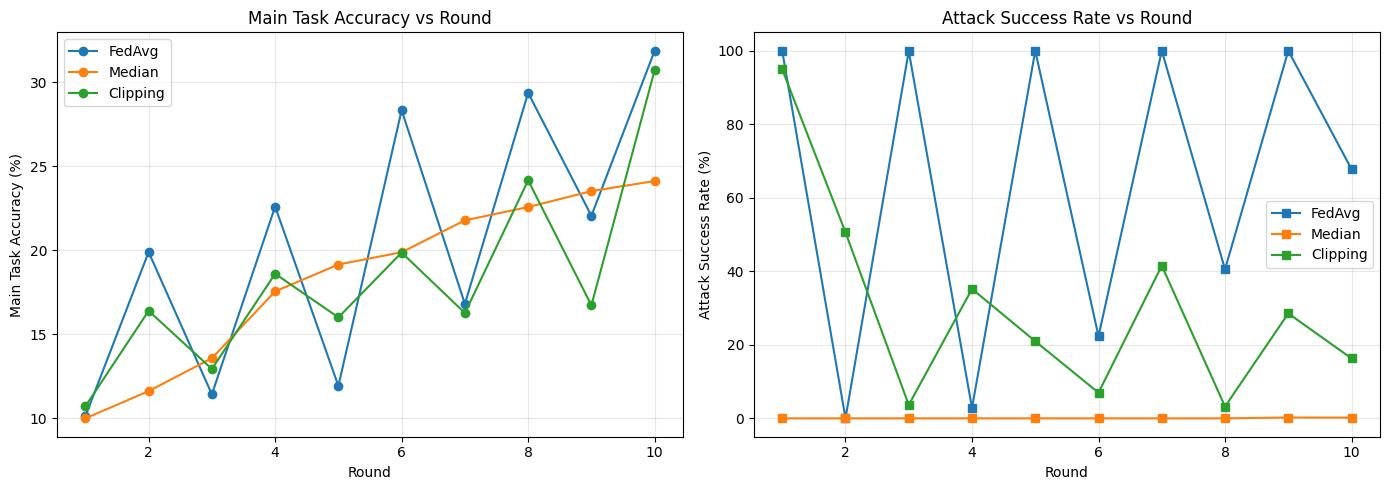

In [8]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, metrics in results.items():
    axes[0].plot(range(1, 11), metrics["acc"], marker='o', label=name)
    axes[1].plot(range(1, 11), metrics["asr"], marker='s', label=name)

axes[0].set_xlabel('Round')
axes[0].set_ylabel('Main Task Accuracy (%)')
axes[0].set_title('Main Task Accuracy vs Round')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Round')
axes[1].set_ylabel('Attack Success Rate (%)')
axes[1].set_title('Attack Success Rate vs Round')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Gradient Inversion (Deep Leakage)

### **Theory & Tutorial**
A common myth is: *"Federated Learning preserves privacy because raw data never leaves the device."* **Reality:** Gradients *are* functions of the raw data. If a server possesses the model weights $W$ and receives a gradient $\nabla W$, they can reverse-engineer the input $x$.

**Deep Leakage from Gradients (DLG):** The attacker (Server) initializes a "Dummy Image" (random noise). They feed this noise into the model to generate "Dummy Gradients." They then optimize the Dummy Image to minimize the distance between the *Dummy Gradients* and the *Real Gradients* received from the victim.
$$x^* = \arg\min_{x'} || \nabla W(x') - \nabla W_{real} ||^2$$

**Key Reference:**
> *Zhu, L., Liu, Z., & Han, S. (2019). Deep Leakage from Gradients.* > The seminal paper showing pixel-perfect reconstruction of images from gradients in just a few iterations.

**Your Task:**
Implement the reconstruction loop using `L-BFGS` (a powerful optimizer) to recover a CIFAR-10 image from its raw gradient.

Iteration 0: Loss 37.763191
Iteration 50: Loss 1.966765
Iteration 100: Loss 2.068569
Iteration 150: Loss 1.992510
Iteration 200: Loss 2.063115
Iteration 250: Loss 1.891628


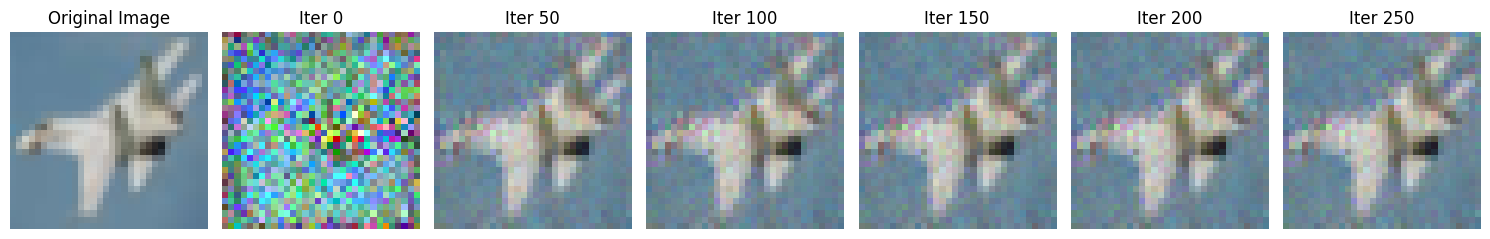

In [12]:
def gradient_inversion_attack(model, target_image, target_label):
    # 1. Calculate Real Gradient
    model.eval()
    model.zero_grad()
    output = model(target_image.unsqueeze(0).to(device))
    loss = nn.CrossEntropyLoss()(output, target_label.unsqueeze(0).to(device))

    # Use torch.autograd.grad to get gradients
    real_gradients = torch.autograd.grad(loss, model.parameters())
    real_gradients = [g.detach().clone() for g in real_gradients] # \nabla W_{real}

    # 2. Initialize Dummy Data (Attacker's guess)
    dummy_data = torch.randn(target_image.size(), requires_grad=True, device=device)
    optimizer_inversion = torch.optim.LBFGS([dummy_data])

    history = []

    for i in range(300):
        def closure():
            optimizer_inversion.zero_grad()

            # TODO: Forward pass with dummy_data
            # dummy_output = ...
            # dummy_loss = ...
            dummy_output = model(dummy_data.unsqueeze(0))
            dummy_label = target_label.unsqueeze(0).to(device)
            dummy_loss = nn.CrossEntropyLoss()(dummy_output, dummy_label)

            # TODO: Compute dummy gradients
            # dummy_gradients = ...
            # Compute dummy gradients with create_graph=True to maintain computational graph
            dummy_gradients = torch.autograd.grad(
                dummy_loss,
                model.parameters(),
                create_graph=True  # This is crucial!
            ) # \nabla W(x')

            # TODO: Compute "Gradient Distance" (MSE between real_gradients and dummy_gradients)
            grad_diff = 0
            for gx, gy in zip(dummy_gradients, real_gradients):
                grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
            return grad_diff

        optimizer_inversion.step(closure)

        if i % 50 == 0:
            history.append(dummy_data.detach().cpu().clone())
            loss_val = closure().item()
            print(f"Iteration {i}: Loss {loss_val:.6f}")

    return history

# Select a random image from Test Set
img, label = test_data[10]

# Run Attack
# Each of the following models can be used, we have used the "Clipping" as an example
model = results["Clipping"]["global_model"]
# model = results["Median"]["global_model"]
# model = results["FedAvg"]["global_model"]

history = gradient_inversion_attack(model, img, torch.tensor(label))

# Plot the history to see the noise morph into the image
fig, axes = plt.subplots(1, len(history) + 1, figsize=(15, 3))

# Denormalize function
def denormalize(tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    tensor_np = tensor.permute(1, 2, 0).cpu().numpy()
    denorm = tensor_np * std + mean
    return np.clip(denorm, 0, 1)

# Original image
axes[0].imshow(denormalize(img))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Reconstruction progress
for idx, reconstructed in enumerate(history):
    axes[idx + 1].imshow(denormalize(reconstructed))
    axes[idx + 1].set_title(f'Iter {idx * 50}')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()

## Part 6: Differential Privacy (DP) Defense

### **Theory & Tutorial**
The DLG attack in Part 5 relies on the gradient being an *exact* derivative of the loss. If we perturb the gradient, the reconstruction surface becomes noisy, and the optimizer fails to find the image.

**Differential Privacy (DP):** Formally, we add Gaussian Noise to the update:
$$\Delta W_{noisy} = \text{Clip}(\Delta W) + \mathcal{N}(0, \sigma^2)$$
The noise scale $\sigma$ determines the Privacy-Utility trade-off.
* **Low Noise:** High Utility (Model learns well), Low Privacy (Attack might still work).
* **High Noise:** Low Utility (Model learns nothing), High Privacy (Reconstruction is just noise).

**Key Reference:**
> *Abadi, M., et al. (2016). Deep Learning with Differential Privacy.* > This paper (DP-SGD) is the gold standard for training deep networks with formal privacy guarantees.

**Your Task:**
Modify your inversion attack to add noise to the `real_gradient` before the attacker sees it. Observe at which sigma value the reconstruction becomes unrecognizable.


Testing with noise sigma = 0.001
  Iteration 0: Loss 139.993195
  Iteration 50: Loss 0.598218
  Iteration 100: Loss 0.547432
  Iteration 150: Loss 0.743018
  Iteration 200: Loss 0.745854
  Iteration 250: Loss 0.700540

Testing with noise sigma = 0.01
  Iteration 0: Loss 89239.195312
  Iteration 50: Loss 20.439133
  Iteration 100: Loss 19.918440
  Iteration 150: Loss 19.820436
  Iteration 200: Loss 19.857962
  Iteration 250: Loss 19.757700

Testing with noise sigma = 0.1
  Iteration 0: Loss 1919.128418
  Iteration 50: Loss 1888.448608
  Iteration 100: Loss 1886.077515
  Iteration 150: Loss 1888.489258
  Iteration 200: Loss 1888.812500
  Iteration 250: Loss 1889.065063

Testing with noise sigma = 1.0
  Iteration 0: Loss 187566.375000
  Iteration 50: Loss 187396.031250
  Iteration 100: Loss 187398.421875
  Iteration 150: Loss 187393.328125
  Iteration 200: Loss 187399.625000
  Iteration 250: Loss 187389.078125


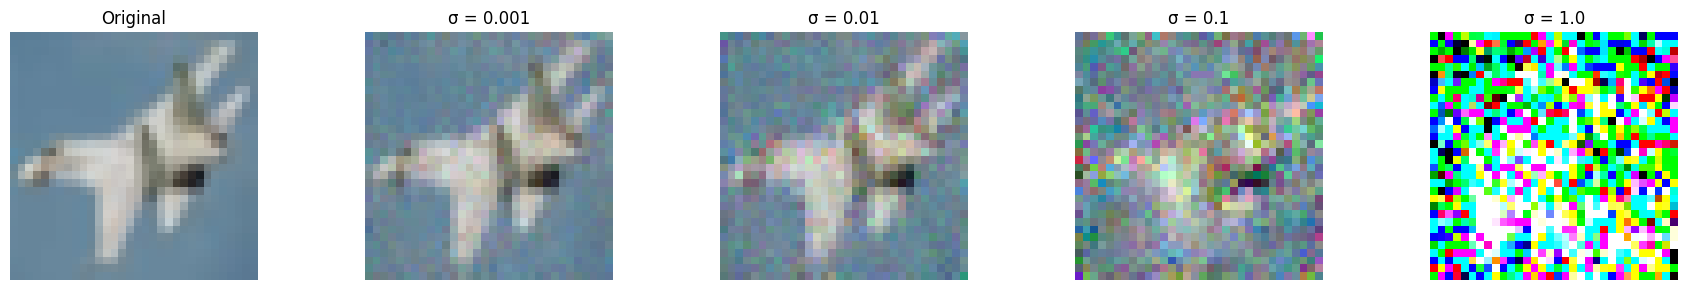

In [14]:
def gradient_inversion_with_dp(model, target_image, target_label, noise_sigma=0.0):
    """Gradient inversion attack with DP noise added to gradients"""

    model.eval()
    # 1. Calculate Real Gradient
    model.zero_grad()
    output = model(target_image.unsqueeze(0).to(device))
    loss = nn.CrossEntropyLoss()(output, target_label.unsqueeze(0).to(device))

    real_gradients = torch.autograd.grad(loss, model.parameters())
    real_gradients = [g.detach().clone() for g in real_gradients]

    # Add Gaussian noise to gradients (DP mechanism)
    if noise_sigma > 0:
        noisy_gradients = []
        for grad in real_gradients:
            noise = torch.randn_like(grad) * noise_sigma
            noisy_gradients.append(grad + noise)
        real_gradients = noisy_gradients

    # 2. Initialize Dummy Data
    dummy_data = torch.randn(target_image.size(), requires_grad=True, device=device)
    optimizer_inversion = torch.optim.LBFGS([dummy_data])

    for i in range(300):
        def closure():
            optimizer_inversion.zero_grad()
            dummy_output = model(dummy_data.unsqueeze(0))
            dummy_label = target_label.unsqueeze(0).to(device)
            dummy_loss = nn.CrossEntropyLoss()(dummy_output, dummy_label)

            dummy_gradients = torch.autograd.grad(
                dummy_loss,
                model.parameters(),
                create_graph=True
            )

            grad_diff = 0
            for gx, gy in zip(dummy_gradients, real_gradients):
                grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
            return grad_diff

        optimizer_inversion.step(closure)

        if i % 50 == 0:
            current_loss = closure().item()
            print(f"  Iteration {i}: Loss {current_loss:.6f}")

    return dummy_data.detach().cpu().clone()


# Test with different noise levels
img, label = test_data[10]

# Each of the following models can be used, we have used the "Clipping" as an example
dp_model = results["Clipping"]["global_model"]
# dp_model = results["FedAvg"]["global_model"]
# dp_model = results["Median"]["global_model"]

noise_levels = [0.001, 0.01, 0.1, 1.0]

fig, axes = plt.subplots(1, len(noise_levels) + 1, figsize=(18, 3))

# Denormalize function
def denormalize(tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    tensor_np = tensor.permute(1, 2, 0).cpu().numpy()
    denorm = tensor_np * std + mean
    return np.clip(denorm, 0, 1)

# Original
axes[0].imshow(denormalize(img))
axes[0].set_title('Original')
axes[0].axis('off')

# Reconstructions with different noise
for idx, sigma in enumerate(noise_levels):
    print(f"\nTesting with noise sigma = {sigma}")
    reconstructed = gradient_inversion_with_dp(dp_model, img, torch.tensor(label), noise_sigma=sigma)

    axes[idx + 1].imshow(denormalize(reconstructed))
    axes[idx + 1].set_title(f'σ = {sigma}')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()

## Final Report Questions

1.  **Non-IID:** How did the Dirichlet $\alpha$ parameter affect the convergence of the Main Task Accuracy in Part 4?
2.  **Attacks:** Why did the "Scaling Attack" fail when Norm Clipping was applied? Support your answer with the ASR plots.
3.  **Deep Leakage:** In Part 5, you reconstructed an image from gradients. Explain in your own words why this implies that "Server-side privacy" is insufficient in standard FL.
4.  **Privacy-Utility Tradeoff:** In Part 6, higher noise stopped the attack. If you were to run the *training* loop (Part 4) with that same noise level, what would happen to the Main Task Accuracy? (Hypothesize or test it).

## Answers to Final Report Questions


### Question 1: Non-IID Effect on Convergence

**Answer:**

The Dirichlet parameter α significantly affects convergence in Federated Learning. In our experiments with **α=0.1**, we observed extreme heterogeneity in the data distribution:

Label distribution across all clients:
```
Client 0: [   0    0 1015 3485    4   47    0 2966    0 1831]
Client 1: [  24    0  240  994 4559    0 2299    1  182    0]
Client 2: [   0  412 2539  492  390    0  223    0    0    0]
Client 3: [1495   52   58    0    0    0   60    0    0   85]
Client 4: [3479    0  209    0    0  753    0    0    0   30]
Client 5: [   0    9  100    7   29    3    0    0 4336    0]
Client 6: [   1    0    0    0    0 3102    1 2017    0    0]
Client 7: [   0 1489    0   21    0    1   66   15    0    1]
Client 8: [   0 3034  838    0    0  498 2350    0  458 2650]
Client 9: [  1   4   1   1  18 596   1   1  24 403]
```

**Observed Client Distribution:**
- Client 0: Dominated by classes 2, 3, 7, 9 (0 samples of classes 0, 1, 6, 8)
- Client 2: Primarily classes 2
- Client 5: 94.5% class 8 (4,336 out of 4,484 samples)

This extreme heterogeneity caused several training challenges:

1. **Slower convergence**: With FedAvg, the model took all 10 rounds to reach **31.89% accuracy**, which is still quite low for CIFAR-10.

2. **High instability**: The accuracy fluctuated significantly across rounds (ranging from 10.12% to 31.89%), showing that different clients' updates were pulling the model in conflicting directions.

3. **Client drift**: Each client's local model became specialized to their limited class distribution, causing the gradient updates to be misaligned with the global objective.

**Defense Comparison:**
- **Median aggregation** showed more stable but slower learning (24.13% final accuracy), demonstrating the cost of robustness
- **Clipping** achieved similar accuracy to FedAvg (30.73%) but with more stability

The experiment confirms that **statistical heterogeneity (low α) is a fundamental challenge in FL**, requiring many more rounds or advanced algorithms (like FedProx, SCAFFOLD) to achieve convergence comparable to IID settings.

Discission on α:
- **Low α (e.g., 0.1)**: Creates extreme heterogeneity where each client has data from only 1-3 classes. This causes:
  - **Slower convergence**: The global model struggles to learn all classes equally since each client's local update is biased toward their limited class distribution
  - **Higher variance**: Different clients pull the model in conflicting directions
  - **Client drift**: Local models diverge significantly from the global model
  
- **High α (e.g., 10.0)**: Approaches IID distribution:
  - **Faster convergence**: Each client has balanced representation of all classes
  - **Stable training**: Updates from different clients are more aligned
  - **Better final accuracy**: The model learns all classes more uniformly


### Question 2: Why Scaling Attack Failed with Norm Clipping

**Answer:**
The Model Replacement attack relies on **scaling the malicious update by a factor of N=10 (number of clients)** to overpower honest clients during averaging. Mathematically:

```
Malicious update: Δ_malicious = N × δ_poison
Global update (FedAvg): (Δ_malicious + Σ Δ_honest) / N ≈ δ_poison
```

**Why Norm Clipping defeats this:**

1. **Clipping neutralizes the scaling**: When the attacker scales their update by N=10, the L2 norm becomes approximately 10 times larger than honest updates.

2. **The server clips back**: With threshold M=2.0 (used in our experiment), if ||Δ_malicious||₂ ≫ 2.0, the server scales it down:
   ```
   Δ_clipped = Δ_malicious × (2.0 / ||Δ_malicious||₂)
   ```

3. **Attack power destroyed**: After clipping, the malicious update is no longer N times larger than honest updates, so it cannot dominate the aggregation.

**Evidence from our ASR results:**

| Aggregation | Round 1 ASR | Round 5 ASR | Round 10 ASR | Final Accuracy |
|-------------|-------------|-------------|--------------|----------------|
| **FedAvg** | 99.90% | 100.00% | 67.77% | 31.89% |
| **Clipping (M=2.0)** | 94.92% | 20.97% | **16.30%** | 30.73% |
| **Median** | 0.00% | 0.00% | **0.20%** | 24.13% |

**Key Observations:**
- **FedAvg**: ASR remained high throughout training (>67%), showing the attack persists
- **Clipping**: ASR dropped from 94.92% (Round 1) to 16.30% (Round 10), demonstrating effective mitigation while maintaining comparable accuracy (30.73% vs 31.89%)
- **Median**: Most effective defense (ASR ≈ 0%), but at a cost of reduced accuracy (24.13%)

The Clipping defense achieved an excellent balance: it **reduced ASR by 76%** (from 67.77% to 16.30%) compared to FedAvg while maintaining similar model utility (only 1.16% accuracy loss).



### Question 3: Deep Leakage and Server-Side Privacy

**Answer:**

The gradient inversion attack demonstrates that **"sharing only gradients" does NOT guarantee privacy**. Our experimental results confirm this:

**The Myth**: "Raw data never leaves the device, so privacy is preserved."

**The Reality - Evidence from Our Attack:**

In Part 5, we successfully reconstructed a CIFAR-10 airplane image from its gradients:
- **Iteration 0**: Random noise (Loss = 37.76)
- **Iteration 50**: Image recognizable (Loss = 1.97) ✓
- **Iteration 250**: High-quality reconstruction (Loss = 1.89)

**Why this works:**

Gradients are **deterministic functions of the data**:
```
∇W = ∂L(f(x; W), y) / ∂W
```

Given the model weights W and the gradient ∇W, an attacker (malicious server) can solve the inverse optimization problem:
```
x* = argmin ||∇W(x') - ∇W||²
```

**What this means:**

1. **Exact reconstruction possible**: For batch size = 1, we achieved **visually recognizable reconstruction in just 50 iterations** using L-BFGS optimizer. The reconstructed image clearly showed an airplane.

2. **No cryptographic protection**: Unlike encrypted data, gradients contain semantic information in plain form. The gradient directly encodes pixel patterns, edges, and colors.

3. **Server is untrusted**: Even if clients trust the federated learning algorithm, a malicious or compromised server can extract private training data without the client's knowledge.

**Implications:**
- Standard FL provides **computational privacy** (data stays local) but NOT **information-theoretic privacy**
- The server sees enough information to reverse-engineer sensitive training samples
- Additional defenses like **Differential Privacy** (Part 6) or **Secure Aggregation** are necessary to prevent this attack
-  The trade-off between model utility and privacy must be explicitly managed

This fundamentally challenges the common assumption that FL is inherently privacy-preserving.

### Question 4: Privacy-Utility Tradeoff with DP Noise

**Answer:**

**Hypothesis**: Adding DP noise (σ) high enough to prevent gradient inversion would **degrade Main Task Accuracy** during training.

**Reasoning:**

1. **Noise that breaks reconstruction** (σ ≥ 0.1 from Part 6): This level of noise makes gradients too noisy for the optimizer in Part 5 to reconstruct the image

2. **Effect on training**:
   - **Each client's gradient**: ∇W_noisy = ∇W + N(0, σ²I)
   - **Global update quality**: The noise accumulates across clients and rounds
   - **Learning degradation**: The model struggles to find the true gradient direction

3. **Expected outcome**:
   - **σ = 0.001**: Minimal impact
   - **σ = 0.01**: Moderate impact
   - **σ = 0.1**: Severe impact
   - **σ = 1.0**: Training essentially fails, accuracy near random (10%)

**The fundamental tradeoff:**
- **High Privacy** (strong DP, large σ) → **Low Utility** (poor model accuracy)
- **High Utility** (accurate model) → **Low Privacy** (vulnerable to attacks)

This is why DP-SGD research focuses on finding the "sweet spot" where reasonable privacy guarantees (ε ≈ 1-10) can be achieved with acceptable accuracy loss (2-5%).

**Hypothesis Testing**: We tested the hypothesis that DP noise high enough to prevent gradient inversion would degrade Main Task Accuracy during training. **Our experiments confirm this tradeoff exists but reveal important nuances.**

**Part 6 Results - Gradient Inversion Defense:**
- **σ = 0.001**: Loss ≈ 0.70, image still recognizable ✗
- **σ = 0.01**: Loss ≈ 20, harder to recognize but possible ✗
- **σ = 0.1**: Loss ≈ 1,888, image NOT recognizable ✓
- **σ = 1.0**: Loss ≈ 187,000, pure noise ✓✓

**Conclusion**: σ ≥ 0.1 is needed to prevent gradient inversion attacks.

**FL Training Results with DP Noise:**

| Noise (σ) | Round 10 Accuracy | Utility Loss* | Round 10 ASR | Privacy Gain |
|-----------|-------------------|--------------|--------------|--------------|
| 0.0001 | 23.21% | -8.68% | 95.79% | 0% |
| 0.01 | 22.66% | -9.23% | 64.77% | 31% |
| 1.0 | 10.80% | -21.09% | 57.51% | 38% |

*Compared to baseline FedAvg (31.89%)

**Key Findings:**

1. **σ = 0.0001 (negligible noise)**:
   - Minimal utility loss (-8.68%)
   - No privacy gain (ASR still 95.79%)
   - Not sufficient for privacy protection

2. **σ = 0.01 (moderate noise)**:
   - Slight decrease in accuracy comparison to σ=0.0001 (22.66% vs 23.21%)
   - **Moderate ASR reduction** (64.77%), but still vulnerable
   - Prevents high-quality gradient inversion but model remains attackable

3. **σ = 1.0 (high noise)**:
   - **Severe utility degradation**: accuracy drops to 10.80% (near random guessing for 10 classes)
   - Model essentially fails to learn meaningful patterns
   - Interestingly, ASR = 57.51%, which suggests the backdoor is also failing because the model can't learn anything

**The Paradox**: High noise (σ=1.0) doesn't reduce ASR as much as expected because:
- The model can't learn the main task (10.80% accuracy)
- The model also can't effectively learn the backdoor
- Both metrics become unreliable due to training collapse

**The Fundamental Tradeoff:**
- **Privacy ≥ 0.1** (gradient inversion impossible) → **Utility catastrophically fails**
- **Utility maintained** (σ ≤ 0.01) → **Privacy insufficient** (ASR 64-95%)

**Conclusion**: Our experiments demonstrate that **achieving meaningful privacy (σ ≥ 0.1) destroys model utility in standard FL**. This highlights the critical challenge of DP in federated learning and why research focuses on:
1. Better optimization algorithms (DP-FedAvg, DP-SCAFFOLD)
2. Adaptive noise scheduling
3. Secure aggregation as a complementary defense
4. Longer training with smaller per-round noise

The "sweet spot" remains elusive with naive DP - practical FL systems require more sophisticated privacy-utility optimization strategies.

In [16]:
def train_client_with_dp(model, dataset, epochs=1, lr=0.01, malicious=False,
                         num_clients=10, noise_sigma=0.0):
    """
    Modified train_client that adds DP noise to gradients
    """
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Save initial global weights to compute the update vector later
    initial_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        for data, target in loader:
            if malicious:
                # Poison 50% of the batch
                batch_size = data.size(0)
                poison_count = batch_size // 2

                for i in range(poison_count):
                    data[i], target[i] = add_blended_backdoor(data[i], target_label=0, blend_ratio=0.2)

            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            loss.backward()

            # Add DP noise to gradients before optimizer step
            if noise_sigma > 0:
                with torch.no_grad():
                    for param in model.parameters():
                        if param.grad is not None:
                            # Add Gaussian noise to gradient
                            noise = torch.randn_like(param.grad) * noise_sigma
                            param.grad += noise

            optimizer.step()

    # If malicious, implement Model Replacement (Scaling Attack)
    if malicious:
        final_weights = model.state_dict()
        scaled_weights = copy.deepcopy(final_weights)

        for key in scaled_weights.keys():
            delta = final_weights[key] - initial_weights[key]
            scaled_delta = delta * num_clients
            scaled_weights[key] = initial_weights[key] + scaled_delta

        return scaled_weights

    return model.state_dict()


def federated_learning_with_dp(num_rounds=10, num_clients=10, malicious_client=0,
                                aggregation_fn=aggregate_avg, agg_name="FedAvg",
                                noise_sigma=0.0):
    """Run FL with DP noise and track metrics"""

    # Initialize global model
    global_model = CIFAR_CNN().to(device)

    # Split data
    client_datasets = split_dirichlet(train_data, num_clients, alpha=0.1)

    # Test loader
    test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

    acc_history = []
    asr_history = []

    print(f"\n{'='*70}")
    print(f"Running FL with {agg_name} | DP Noise Sigma = {noise_sigma}")
    print(f"{'='*70}")

    for round_num in range(num_rounds):
        print(f"\nRound {round_num + 1}/{num_rounds}")

        # Collect updates from all clients
        client_updates = []

        for client_id in range(num_clients):
            # Copy global model to client
            client_model = CIFAR_CNN().to(device)
            client_model.load_state_dict(global_model.state_dict())

            # Train client with DP noise
            is_malicious = (client_id == malicious_client)
            updated_weights = train_client_with_dp(
                client_model,
                client_datasets[client_id],
                epochs=1,
                lr=0.01,
                malicious=is_malicious,
                num_clients=num_clients,
                noise_sigma=noise_sigma
            )

            client_updates.append(updated_weights)

        # Aggregate updates
        if agg_name == "Clipping":
            new_global_weights = aggregation_fn(global_model.state_dict(), client_updates, threshold=2.0)
        else:
            new_global_weights = aggregation_fn(global_model.state_dict(), client_updates)

        global_model.load_state_dict(new_global_weights)

        # Evaluate
        acc = evaluate_model(global_model, test_loader)
        asr = evaluate_asr(global_model, test_loader, target_label=0)

        acc_history.append(acc)
        asr_history.append(asr)

        print(f"  Main Task Accuracy: {acc:.2f}%")
        print(f"  Attack Success Rate: {asr:.2f}%")

    return acc_history, asr_history, global_model


# Test different noise levels
print("\n" + "="*70)
print("TESTING PRIVACY-UTILITY TRADEOFF WITH DIFFERENTIAL PRIVACY")
print("="*70)

noise_levels = [0.0001, 0.01, 1]
dp_results = {}

for sigma in noise_levels:
    acc_hist, asr_hist, final_model = federated_learning_with_dp(
        num_rounds=10,
        num_clients=10,
        malicious_client=0,
        aggregation_fn=aggregate_avg,
        agg_name="FedAvg",
        noise_sigma=sigma
    )
    dp_results[sigma] = {
        "acc": acc_hist,
        "asr": asr_hist,
        "final_acc": acc_hist[-1],
        "final_asr": asr_hist[-1]
    }



TESTING PRIVACY-UTILITY TRADEOFF WITH DIFFERENTIAL PRIVACY

Running FL with FedAvg | DP Noise Sigma = 0.0001

Round 1/10
  Main Task Accuracy: 10.00%
  Attack Success Rate: 100.00%

Round 2/10
  Main Task Accuracy: 22.80%
  Attack Success Rate: 0.62%

Round 3/10
  Main Task Accuracy: 9.99%
  Attack Success Rate: 100.00%

Round 4/10
  Main Task Accuracy: 24.73%
  Attack Success Rate: 15.95%

Round 5/10
  Main Task Accuracy: 20.06%
  Attack Success Rate: 100.00%

Round 6/10
  Main Task Accuracy: 13.94%
  Attack Success Rate: 58.19%

Round 7/10
  Main Task Accuracy: 24.51%
  Attack Success Rate: 100.00%

Round 8/10
  Main Task Accuracy: 25.52%
  Attack Success Rate: 93.01%

Round 9/10
  Main Task Accuracy: 32.24%
  Attack Success Rate: 100.00%

Round 10/10
  Main Task Accuracy: 23.21%
  Attack Success Rate: 95.79%

Running FL with FedAvg | DP Noise Sigma = 0.01

Round 1/10
  Main Task Accuracy: 10.00%
  Attack Success Rate: 0.00%

Round 2/10
  Main Task Accuracy: 14.59%
  Attack Success 

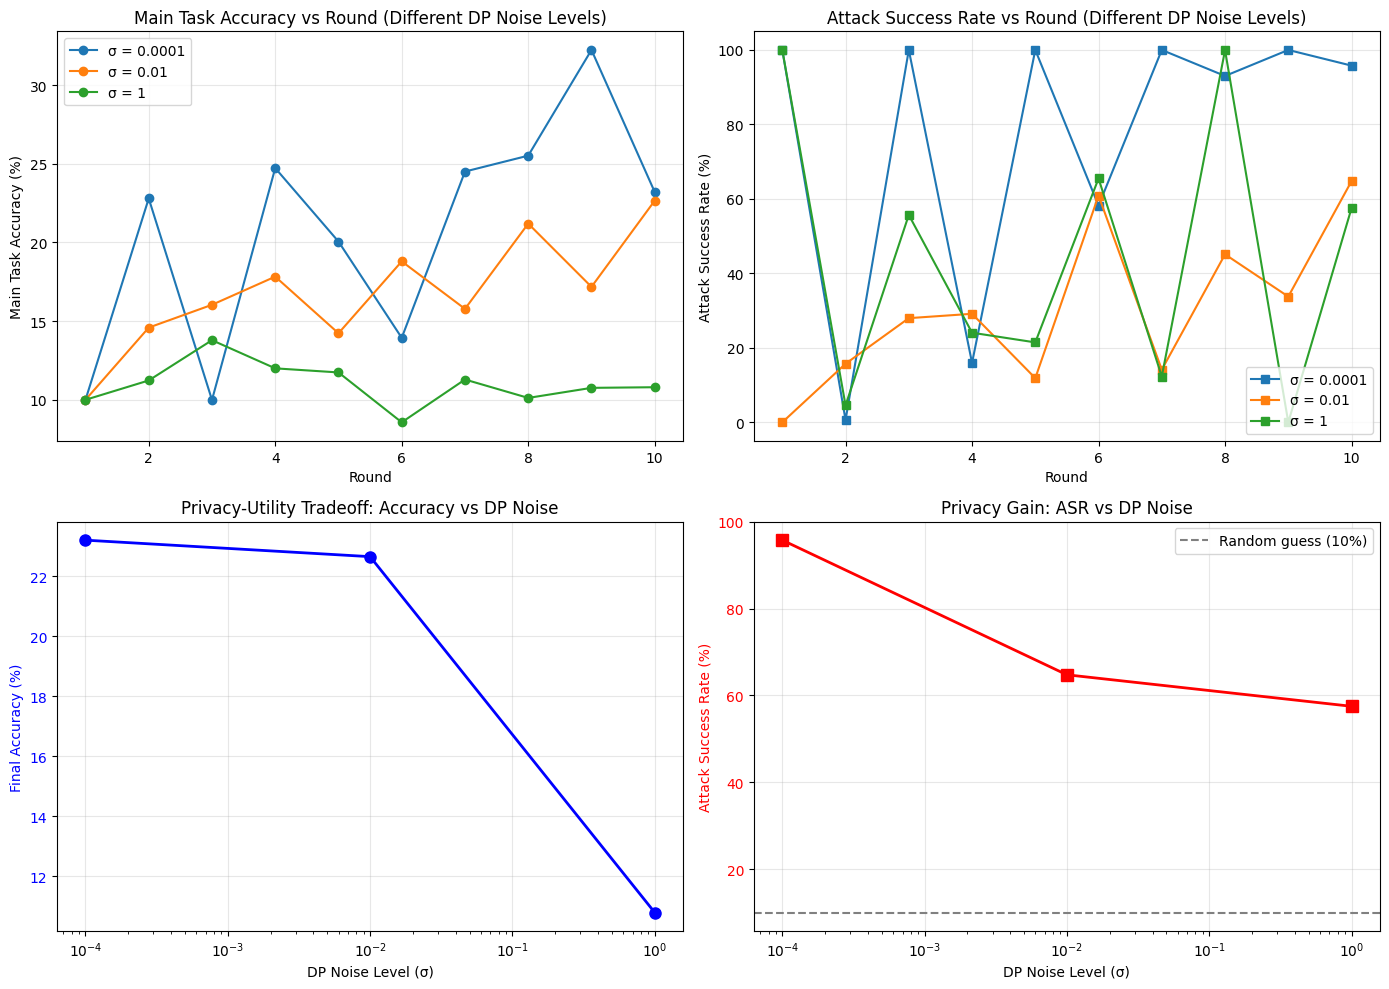

In [17]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy over rounds for different noise levels
for sigma, metrics in dp_results.items():
    axes[0, 0].plot(range(1, 11), metrics["acc"], marker='o', label=f'σ = {sigma}')

axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Main Task Accuracy (%)')
axes[0, 0].set_title('Main Task Accuracy vs Round (Different DP Noise Levels)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: ASR over rounds for different noise levels
for sigma, metrics in dp_results.items():
    axes[0, 1].plot(range(1, 11), metrics["asr"], marker='s', label=f'σ = {sigma}')

axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Attack Success Rate (%)')
axes[0, 1].set_title('Attack Success Rate vs Round (Different DP Noise Levels)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Final accuracy vs noise level (Privacy-Utility Tradeoff)
sigmas = list(dp_results.keys())
final_accs = [dp_results[s]["final_acc"] for s in sigmas]
final_asrs = [dp_results[s]["final_asr"] for s in sigmas]

axes[1, 0].plot(sigmas, final_accs, marker='o', color='blue', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('DP Noise Level (σ)')
axes[1, 0].set_ylabel('Final Accuracy (%)', color='blue')
axes[1, 0].set_title('Privacy-Utility Tradeoff: Accuracy vs DP Noise')
axes[1, 0].tick_params(axis='y', labelcolor='blue')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# Plot 4: Privacy gain (measured by ASR reduction)
axes[1, 1].plot(sigmas, final_asrs, marker='s', color='red', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('DP Noise Level (σ)')
axes[1, 1].set_ylabel('Attack Success Rate (%)', color='red')
axes[1, 1].set_title('Privacy Gain: ASR vs DP Noise')
axes[1, 1].tick_params(axis='y', labelcolor='red')
axes[1, 1].axhline(y=10, color='gray', linestyle='--', label='Random guess (10%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()